# Week 2 - Data Preprocessing & Feature Engineering

### Objective:
Transform raw financial market data into a clean, structured dataset suitable for quantitative modeling. This week focuses on data preprocessing, including data cleaning, missing value handling, outlier detection, and time alignment, followed by feature engineering using financial indicators such as daily returns, historical volatility, moving averages, momentum, VIX, and Treasury rates. The final goal is to build a reproducible preprocessing pipeline and generate a feature-rich dataset for subsequent model development.

## Required Packages

In [187]:
import pandas as pd
import numpy as np

from pathlib import Path

# 1. Local Data Repathing

In [188]:
DATA_DIR = Path("../Week1/raw_data")

jpm = pd.read_csv(DATA_DIR / "JPM_Yahoo_2018_2024.csv")
vix = pd.read_csv(DATA_DIR / "VIX_2018_2024.csv")
treasury = pd.read_csv(DATA_DIR / "Treasury_2018_2024.csv")
alpha = pd.read_csv(DATA_DIR / "JPM_AlphaVantage_compact_2026.csv")  # API connection test only

jpm.head()

,Price,Close,High,Low,Open,Volume
0,Ticker,JPM,JPM,JPM,JPM,JPM
1,Date,NaN,NaN,NaN,NaN,NaN
2,2018-01-02,85.51602935791016,85.57148184634795,84.61294252114149,85.26253140449909,13578800
3,2018-01-03,85.60317993164062,85.94381841328286,85.14371899210931,85.44474595854275,11901000
4,2018-01-04,86.82948303222656,87.61782677757108,86.16058070636457,86.28799298761523,12953700


# 2. Reusable Cleaning Functions

General functions for all datasets which include:

- Invalid leading rows removing.
- Interpolations handling.
- Outliers detection.
- Time alignment.

In [189]:
def remove_invalid_leading_rows(df, date_column="Date"):
    """
    Remove consecutive leading rows whose date values cannot be parsed.

    Parameters
    ----------
    df : pandas.DataFrame
        Input dataset.
    date_column : str
        Name of the date column.

    Returns
    -------
    pandas.DataFrame
        Dataset beginning with the first valid dated observation.
    """
    cleaned_df = df.copy()

    while not cleaned_df.empty:
        first_date = pd.to_datetime(
            cleaned_df.iloc[0][date_column],
            errors="coerce"
        )

        if pd.notna(first_date):
            break

        cleaned_df = cleaned_df.iloc[1:].reset_index(drop=True)

    return cleaned_df

In [190]:
def interpolate_missing_values(
        df,
        columns,
        date_column="Date",
        method="time",
        limit_direction="both"
):
    """
    Interpolate missing values in selected columns.

    For method='time', the date column is temporarily used as the index.
    """
    interpolated_df = df.copy()

    interpolated_df[date_column] = pd.to_datetime(
        interpolated_df[date_column],
        errors="coerce"
    )

    interpolated_df = (
        interpolated_df
        .sort_values(date_column)
        .reset_index(drop=True)
    )

    missing_columns = [
        column
        for column in columns
        if column not in interpolated_df.columns
    ]

    if missing_columns:
        raise KeyError(
            f"Columns not found in DataFrame: {missing_columns}"
        )

    if method == "time":
        interpolated_df = interpolated_df.set_index(date_column)

        interpolated_df[columns] = (
            interpolated_df[columns]
            .interpolate(
                method="time",
                limit_direction=limit_direction
            )
        )

        interpolated_df = interpolated_df.reset_index()

    else:
        interpolated_df[columns] = (
            interpolated_df[columns]
            .interpolate(
                method=method,
                limit_direction=limit_direction
            )
        )

    return interpolated_df

In [191]:
def detect_iqr_outliers(
        df,
        columns,
        multiplier=1.5,
        add_flags=True
):
    """
    Detect outliers using the IQR method.

    Parameters
    ----------
    df : pandas.DataFrame
        Input dataset.
    columns : list
        Numeric columns used for outlier detection.
    multiplier : float
        IQR multiplier. Standard value is 1.5.
    add_flags : bool
        Whether to add Boolean outlier flag columns.

    Returns
    -------
    flagged_df : pandas.DataFrame
        Dataset with optional outlier flags.
    summary_df : pandas.DataFrame
        IQR bounds and outlier counts for each column.
    """
    flagged_df = df.copy()
    summary = []

    for column in columns:
        if column not in flagged_df.columns:
            raise KeyError(f"Column not found: {column}")

        series = pd.to_numeric(
            flagged_df[column],
            errors="coerce"
        )

        q1 = series.quantile(0.25)
        q3 = series.quantile(0.75)
        iqr = q3 - q1

        lower_bound = q1 - multiplier * iqr
        upper_bound = q3 + multiplier * iqr

        outlier_mask = (
                (series < lower_bound)
                | (series > upper_bound)
        )

        if add_flags:
            flagged_df[f"{column}_Outlier"] = outlier_mask

        summary.append({
            "Feature": column,
            "Q1": q1,
            "Q3": q3,
            "IQR": iqr,
            "Lower_Bound": lower_bound,
            "Upper_Bound": upper_bound,
            "Outlier_Count": int(outlier_mask.sum())
        })

    summary_df = pd.DataFrame(summary)

    return flagged_df, summary_df

In [192]:
def align_time_series(
        base_df,
        other_dfs,
        date_column="Date",
        how="left",
        fill_columns=None,
        fill_method="ffill"
):
    """
    Align multiple time-series datasets to a base date index.

    Parameters
    ----------
    base_df : pandas.DataFrame
        Main dataset whose dates define the final timeline.
    other_dfs : list of pandas.DataFrame
        Additional datasets to merge.
    date_column : str
        Shared date column.
    how : str
        Merge method. Usually 'left' for financial alignment.
    fill_columns : list or None
        Columns to fill after alignment.
    fill_method : str
        Supported values: 'ffill', 'bfill', or 'both'.

    Returns
    -------
    pandas.DataFrame
        Time-aligned merged dataset.
    """
    aligned_df = base_df.copy()

    aligned_df[date_column] = pd.to_datetime(
        aligned_df[date_column],
        errors="coerce"
    )

    aligned_df = (
        aligned_df
        .dropna(subset=[date_column])
        .sort_values(date_column)
        .drop_duplicates(subset=[date_column], keep="last")
        .reset_index(drop=True)
    )

    for other_df in other_dfs:
        current_df = other_df.copy()

        current_df[date_column] = pd.to_datetime(
            current_df[date_column],
            errors="coerce"
        )

        current_df = (
            current_df
            .dropna(subset=[date_column])
            .sort_values(date_column)
            .drop_duplicates(subset=[date_column], keep="last")
        )

        aligned_df = aligned_df.merge(
            current_df,
            on=date_column,
            how=how
        )

    aligned_df = (
        aligned_df
        .sort_values(date_column)
        .reset_index(drop=True)
    )

    if fill_columns:
        missing_columns = [
            column
            for column in fill_columns
            if column not in aligned_df.columns
        ]

        if missing_columns:
            raise KeyError(
                f"Columns not found after merging: {missing_columns}"
            )

        if fill_method == "ffill":
            aligned_df[fill_columns] = (
                aligned_df[fill_columns].ffill()
            )

        elif fill_method == "bfill":
            aligned_df[fill_columns] = (
                aligned_df[fill_columns].bfill()
            )

        elif fill_method == "both":
            aligned_df[fill_columns] = (
                aligned_df[fill_columns]
                .ffill()
                .bfill()
            )

        else:
            raise ValueError(
                "fill_method must be 'ffill', 'bfill', or 'both'."
            )

    return aligned_df

# 3. Yahoo JPM Cleaning

This section standardizes the Yahoo Finance JPM dataset by:

- Renaming columns.
- Removing invalid leading rows.
- Converting date and numeric columns to appropriate data types.
- Sorting observations chronologically.
- Removing duplicate dates.
- Inspecting missing values.

In [193]:
# Standardize Yahoo Finance JPM column names
jpm.columns = [
    "Date",
    "Close",
    "High",
    "Low",
    "Open",
    "Volume"
]

# Remove invalid leading rows
jpm = remove_invalid_leading_rows(
    jpm,
    date_column="Date"
)

# Convert date and numeric columns
jpm["Date"] = pd.to_datetime(
    jpm["Date"],
    errors="coerce"
)

jpm_numeric_columns = [
    "Open",
    "High",
    "Low",
    "Close",
    "Volume"
]

jpm[jpm_numeric_columns] = jpm[jpm_numeric_columns].apply(
    pd.to_numeric,
    errors="coerce"
)

# Sort observations and remove duplicate dates
jpm = (
    jpm
    .dropna(subset=["Date"])
    .sort_values("Date")
    .drop_duplicates(subset="Date", keep="last")
    .reset_index(drop=True)
)

jpm.head()

,Date,Close,High,Low,Open,Volume
0,2018-01-02,85.516029,85.571482,84.612943,85.262531,13578800
1,2018-01-03,85.603180,85.943818,85.143719,85.444746,11901000
2,2018-01-04,86.829483,87.617827,86.160581,86.287993,12953700
3,2018-01-05,86.272064,87.235603,85.826133,87.004673,14155000
4,2018-01-08,86.399475,86.542811,85.762426,86.120768,12466500


In [194]:
#Interpolation
jpm_price_columns = [
    "Open",
    "High",
    "Low",
    "Close"
]

if jpm[jpm_price_columns].isna().any().any():
    jpm = interpolate_missing_values(
        jpm,
        columns=jpm_price_columns,
        date_column="Date"
    )

jpm.head()

,Date,Close,High,Low,Open,Volume
0,2018-01-02,85.516029,85.571482,84.612943,85.262531,13578800
1,2018-01-03,85.603180,85.943818,85.143719,85.444746,11901000
2,2018-01-04,86.829483,87.617827,86.160581,86.287993,12953700
3,2018-01-05,86.272064,87.235603,85.826133,87.004673,14155000
4,2018-01-08,86.399475,86.542811,85.762426,86.120768,12466500


# 4. VIX Cleaning

This section standardizes the VIX dataset and prepares it for integration with JPM market data.

In [195]:
vix.columns = [
    "Date",
    "VIX_Close",
    "VIX_High",
    "VIX_Low",
    "VIX_Open",
    "VIX_Volume"
]

vix = remove_invalid_leading_rows(
    vix,
    date_column="Date"
)

vix["Date"] = pd.to_datetime(
    vix["Date"],
    errors="coerce"
)

vix_numeric_columns = [
    "VIX_Open",
    "VIX_High",
    "VIX_Low",
    "VIX_Close",
    "VIX_Volume"
]

vix[vix_numeric_columns] = vix[vix_numeric_columns].apply(
    pd.to_numeric,
    errors="coerce"
)

vix = (
    vix
    .dropna(subset=["Date"])
    .sort_values("Date")
    .drop_duplicates(subset="Date", keep="last")
    .reset_index(drop=True)
)

vix.head()

,Date,VIX_Close,VIX_High,VIX_Low,VIX_Open,VIX_Volume
0,2018-01-02,9.77,11.07,9.52,10.95,0
1,2018-01-03,9.15,9.65,8.94,9.56,0
2,2018-01-04,9.22,9.31,8.92,9.01,0
3,2018-01-05,9.22,9.54,9.00,9.10,0
4,2018-01-08,9.52,9.89,9.32,9.61,0


In [196]:
vix.isna().sum()

Date          0
VIX_Close     0
VIX_High      0
VIX_Low       0
VIX_Open      0
VIX_Volume    0
dtype: int64

In [197]:
#Interpolation
vix_price_columns = [
    "VIX_Open",
    "VIX_High",
    "VIX_Low",
    "VIX_Close"
]

if vix[vix_price_columns].isna().any().any():
    vix = interpolate_missing_values(
        vix,
        columns=vix_price_columns,
        date_column="Date"
    )

vix.head()

,Date,VIX_Close,VIX_High,VIX_Low,VIX_Open,VIX_Volume
0,2018-01-02,9.77,11.07,9.52,10.95,0
1,2018-01-03,9.15,9.65,8.94,9.56,0
2,2018-01-04,9.22,9.31,8.92,9.01,0
3,2018-01-05,9.22,9.54,9.00,9.10,0
4,2018-01-08,9.52,9.89,9.32,9.61,0


# 5. Treasury Rate Cleaning

This section standardizes Treasury yield data and prepares it for time alignment with JPM trading dates.

In [198]:
treasury.columns = [
    "Date",
    "Treasury_Rate"
]

treasury["Date"] = pd.to_datetime(
    treasury["Date"],
    errors="coerce"
)

treasury["Treasury_Rate"] = pd.to_numeric(
    treasury["Treasury_Rate"],
    errors="coerce"
)

treasury = (
    treasury
    .dropna(subset=["Date"])
    .sort_values("Date")
    .drop_duplicates(subset="Date", keep="last")
    .reset_index(drop=True)
)

treasury.head()

,Date,Treasury_Rate
0,2018-01-01,NaN
1,2018-01-02,2.46
2,2018-01-03,2.44
3,2018-01-04,2.46
4,2018-01-05,2.47


In [199]:
#Interpolation
if treasury[["Treasury_Rate"]].isna().any().any():
    treasury = interpolate_missing_values(
        treasury,
        columns=["Treasury_Rate"],
        date_column="Date"
    )
treasury.head()

,Date,Treasury_Rate
0,2018-01-01,2.46
1,2018-01-02,2.46
2,2018-01-03,2.44
3,2018-01-04,2.46
4,2018-01-05,2.47


# 6. Outlier Detection

The IQR method is used to identify unusually large observations in selected raw market variables. Outliers are flagged rather than removed because extreme market movements may represent genuine financial events.

In [200]:
jpm, jpm_outlier_summary = detect_iqr_outliers(
    jpm,
    columns=["Volume"]
)

vix, vix_outlier_summary = detect_iqr_outliers(
    vix,
    columns=["VIX_Close"]
)

treasury, treasury_outlier_summary = detect_iqr_outliers(
    treasury,
    columns=["Treasury_Rate"]
)

In [201]:
jpm

,Date,Close,High,Low,Open,Volume,Volume_Outlier
0,2018-01-02,85.516029,85.571482,84.612943,85.262531,13578800,False
1,2018-01-03,85.603180,85.943818,85.143719,85.444746,11901000,False
2,2018-01-04,86.829483,87.617827,86.160581,86.287993,12953700,False
3,2018-01-05,86.272064,87.235603,85.826133,87.004673,14155000,False
4,2018-01-08,86.399475,86.542811,85.762426,86.120768,12466500,False
...,...,...,...,...,...,...,...
1755,2024-12-23,230.179596,230.401670,226.790489,227.939507,8611500,False
1756,2024-12-24,233.964584,234.138393,230.836183,231.183770,3729100,False
1757,2024-12-26,234.766006,234.881869,232.496937,233.114894,4451800,False
1758,2024-12-27,232.863876,235.007419,231.772790,234.360496,5730200,False


In [202]:
jpm_outlier_summary

,Feature,Q1,Q3,IQR,Lower_Bound,Upper_Bound,Outlier_Count
0,Volume,8989225.0,15164450.0,6175225.0,-273612.5,24427287.5,118


In [203]:
vix

,Date,VIX_Close,VIX_High,VIX_Low,VIX_Open,VIX_Volume,VIX_Close_Outlier
0,2018-01-02,9.770000,11.070000,9.520000,10.950000,0,False
1,2018-01-03,9.150000,9.650000,8.940000,9.560000,0,False
2,2018-01-04,9.220000,9.310000,8.920000,9.010000,0,False
3,2018-01-05,9.220000,9.540000,9.000000,9.100000,0,False
4,2018-01-08,9.520000,9.890000,9.320000,9.610000,0,False
...,...,...,...,...,...,...,...
1755,2024-12-23,16.780001,20.020000,16.740000,18.090000,0,False
1756,2024-12-24,14.270000,17.040001,14.270000,16.969999,0,False
1757,2024-12-26,14.730000,15.930000,14.550000,14.990000,0,False
1758,2024-12-27,15.950000,18.450001,15.290000,15.380000,0,False


In [204]:
vix_outlier_summary

,Feature,Q1,Q3,IQR,Lower_Bound,Upper_Bound,Outlier_Count
0,VIX_Close,14.4775,22.892499,8.415,1.855,35.514999,53


In [205]:
treasury

,Date,Treasury_Rate,Treasury_Rate_Outlier
0,2018-01-01,2.460,False
1,2018-01-02,2.460,False
2,2018-01-03,2.440,False
3,2018-01-04,2.460,False
4,2018-01-05,2.470,False
...,...,...,...
1822,2024-12-25,4.585,False
1823,2024-12-26,4.580,False
1824,2024-12-27,4.620,False
1825,2024-12-30,4.550,False


In [206]:
treasury_outlier_summary

,Feature,Q1,Q3,IQR,Lower_Bound,Upper_Bound,Outlier_Count
0,Treasury_Rate,1.5975,3.74,2.1425,-1.61625,6.95375,0


# 7. Time Alignment

JPM trading dates are used as the primary timeline. VIX and Treasury data are aligned to the JPM trading calendar using left joins.

In [207]:
vix_for_merge = vix[
    [
        "Date",
        "VIX_Close",
        "VIX_Close_Outlier"
    ]
].copy()

treasury_for_merge = treasury[
    [
        "Date",
        "Treasury_Rate",
        "Treasury_Rate_Outlier"
    ]
].copy()

market_data = align_time_series(
    base_df=jpm,
    other_dfs=[
        vix_for_merge,
        treasury_for_merge
    ],
    date_column="Date",
    how="left",
    fill_columns=[
        "VIX_Close",
        "Treasury_Rate"
    ],
    fill_method="both"
)

market_data.head()

,Date,Close,High,Low,Open,Volume,Volume_Outlier,VIX_Close,VIX_Close_Outlier,Treasury_Rate,Treasury_Rate_Outlier
0,2018-01-02,85.516029,85.571482,84.612943,85.262531,13578800,False,9.77,False,2.46,False
1,2018-01-03,85.603180,85.943818,85.143719,85.444746,11901000,False,9.15,False,2.44,False
2,2018-01-04,86.829483,87.617827,86.160581,86.287993,12953700,False,9.22,False,2.46,False
3,2018-01-05,86.272064,87.235603,85.826133,87.004673,14155000,False,9.22,False,2.47,False
4,2018-01-08,86.399475,86.542811,85.762426,86.120768,12466500,False,9.52,False,2.49,False


In [208]:
market_data.isna().sum()

Date                     0
Close                    0
High                     0
Low                      0
Open                     0
Volume                   0
Volume_Outlier           0
VIX_Close                0
VIX_Close_Outlier        0
Treasury_Rate            0
Treasury_Rate_Outlier    0
dtype: int64

# 8. Feature Engineering

Financial features are constructed from the cleaned and time-aligned market dataset. These features capture JPM returns, price trends, historical volatility, market momentum, interest-rate movements, and the dynamic relationship between JPM and the VIX index.

In [209]:
def engineer_features(
        df,
        price_column="Close",
        vix_column="VIX_Close",
        rate_column="Treasury_Rate",
        trading_days=252
):
    """
    Construct financial features from cleaned and aligned market data.

    Parameters
    ----------
    df : pandas.DataFrame
        Cleaned and time-aligned market dataset.
    price_column : str
        JPM closing price column.
    vix_column : str
        VIX closing price column.
    rate_column : str
        Treasury rate column.
    trading_days : int
        Number of trading days used for annualization.

    Returns
    -------
    pandas.DataFrame
        Dataset with engineered financial features.
    """
    feature_df = df.copy()

    required_columns = [
        price_column,
        vix_column,
        rate_column
    ]

    missing_columns = [
        column
        for column in required_columns
        if column not in feature_df.columns
    ]

    if missing_columns:
        raise KeyError(
            f"Required columns not found: {missing_columns}"
        )

    # Daily percentage return of JPM closing price
    feature_df["Daily_Return"] = (
        feature_df[price_column].pct_change()
    )

    # Log return of JPM closing price
    feature_df["Log_Return"] = np.log(
        feature_df[price_column]
        / feature_df[price_column].shift(1)
    )

    # Annualized 20-day rolling historical volatility
    feature_df["Rolling_Volatility_20D"] = (
            feature_df["Daily_Return"]
            .rolling(window=20)
            .std()
            * np.sqrt(trading_days)
    )

    # 20-day moving average
    feature_df["Moving_Average_20D"] = (
        feature_df[price_column]
        .rolling(window=20)
        .mean()
    )

    # 50-day moving average
    feature_df["Moving_Average_50D"] = (
        feature_df[price_column]
        .rolling(window=50)
        .mean()
    )

    # 20-day percentage price momentum
    feature_df["Price_Momentum_20D"] = (
        feature_df[price_column]
        .pct_change(periods=20)
    )

    # Daily change in Treasury rate
    feature_df["Interest_Rate_Momentum"] = (
        feature_df[rate_column]
        .diff()
    )

    # Daily percentage return of VIX
    feature_df["VIX_Return"] = (
        feature_df[vix_column]
        .pct_change()
    )

    # 20-day rolling correlation between JPM and VIX returns
    feature_df["VIX_JPM_Correlation_20D"] = (
        feature_df["Daily_Return"]
        .rolling(window=20)
        .corr(feature_df["VIX_Return"])
    )

    return feature_df

In [210]:
market_data = engineer_features(market_data)

In [211]:
market_data.head()

,Date,Close,High,Low,Open,Volume,Volume_Outlier,VIX_Close,VIX_Close_Outlier,Treasury_Rate,Treasury_Rate_Outlier,Daily_Return,Log_Return,Rolling_Volatility_20D,Moving_Average_20D,Moving_Average_50D,Price_Momentum_20D,Interest_Rate_Momentum,VIX_Return,VIX_JPM_Correlation_20D
0,2018-01-02,85.516029,85.571482,84.612943,85.262531,13578800,False,9.77,False,2.46,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2018-01-03,85.603180,85.943818,85.143719,85.444746,11901000,False,9.15,False,2.44,False,0.001019,0.001019,NaN,NaN,NaN,NaN,-0.02,-0.063460,NaN
2,2018-01-04,86.829483,87.617827,86.160581,86.287993,12953700,False,9.22,False,2.46,False,0.014325,0.014224,NaN,NaN,NaN,NaN,0.02,0.007650,NaN
3,2018-01-05,86.272064,87.235603,85.826133,87.004673,14155000,False,9.22,False,2.47,False,-0.006420,-0.006440,NaN,NaN,NaN,NaN,0.01,0.000000,NaN
4,2018-01-08,86.399475,86.542811,85.762426,86.120768,12466500,False,9.52,False,2.49,False,0.001477,0.001476,NaN,NaN,NaN,NaN,0.02,0.032538,NaN


In [212]:
market_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1760 entries, 0 to 1759
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Date                     1760 non-null   datetime64[us]
 1   Close                    1760 non-null   float64       
 2   High                     1760 non-null   float64       
 3   Low                      1760 non-null   float64       
 4   Open                     1760 non-null   float64       
 5   Volume                   1760 non-null   int64         
 6   Volume_Outlier           1760 non-null   bool          
 7   VIX_Close                1760 non-null   float64       
 8   VIX_Close_Outlier        1760 non-null   bool          
 9   Treasury_Rate            1760 non-null   float64       
 10  Treasury_Rate_Outlier    1760 non-null   bool          
 11  Daily_Return             1759 non-null   float64       
 12  Log_Return               1759 non-null   floa

In [213]:
market_data.describe()

,Date,Close,High,Low,Open,Volume,VIX_Close,Treasury_Rate,Daily_Return,Log_Return,Rolling_Volatility_20D,Moving_Average_20D,Moving_Average_50D,Price_Momentum_20D,Interest_Rate_Momentum,VIX_Return,VIX_JPM_Correlation_20D
count,1760,1760.000000,1760.000000,1760.000000,1760.000000,1.760000e+03,1760.000000,1760.000000,1759.000000,1759.000000,1740.000000,1741.000000,1711.000000,1740.000000,1759.000000,1759.000000,1740.000000
mean,2021-06-30 22:10:21.818181,122.424267,123.581355,121.236115,122.399530,1.322733e+07,19.871136,2.641553,0.000738,0.000565,0.253993,122.017837,121.318575,0.013914,0.001188,0.003797,-0.495317
min,2018-01-02 00:00:00,66.463898,70.433399,64.680999,68.591624,3.220500e+06,9.150000,0.520000,-0.149649,-0.162106,0.074440,75.386226,76.812147,-0.402013,-0.300000,-0.281566,-0.908261
25%,2019-10-01 18:00:00,90.884237,91.640737,89.880633,90.844907,8.989225e+06,14.477500,1.590000,-0.007775,-0.007805,0.170531,90.624695,90.781360,-0.026290,-0.030000,-0.043932,-0.687077
50%,2021-06-30 12:00:00,115.615894,116.351756,114.980956,115.635781,1.158615e+07,18.040001,2.790000,0.000668,0.000668,0.221800,115.034989,114.234375,0.013977,0.000000,-0.008021,-0.528311
75%,2023-03-30 06:00:00,139.184422,140.461207,138.035050,139.111591,1.516445e+07,22.892499,3.740000,0.009122,0.009080,0.278790,139.071912,138.660846,0.057130,0.030000,0.035117,-0.350422
max,2024-12-30 00:00:00,241.669739,245.551290,240.858680,241.862858,5.441880e+07,82.690002,4.980000,0.180125,0.165620,1.364336,236.957827,229.299013,0.289231,0.290000,1.155979,0.349257
std,NaN,37.523742,37.721172,37.280551,37.485610,6.575726e+06,7.713274,1.209314,0.018646,0.018608,0.157311,36.578578,34.996928,0.073921,0.057008,0.088510,0.241395


# 9. IQR for Features

In [214]:
# Detect unusually large values in selected engineered features
market_data, feature_outlier_summary = detect_iqr_outliers(
    market_data,
    columns=[
        "Daily_Return",
        "Rolling_Volatility_20D",
        "Price_Momentum_20D"
    ]
)

feature_outlier_summary

,Feature,Q1,Q3,IQR,Lower_Bound,Upper_Bound,Outlier_Count
0,Daily_Return,-0.007775,0.009122,0.016897,-0.033120,0.034467,95
1,Rolling_Volatility_20D,0.170531,0.278790,0.108259,0.008142,0.441179,121
2,Price_Momentum_20D,-0.026290,0.057130,0.083420,-0.151421,0.182260,49


# 10. Data Saving

In [215]:
OUTPUT_DIR = Path("./processed_data")
OUTPUT_DIR.mkdir(exist_ok=True)

market_data.to_csv(
    OUTPUT_DIR / "market_data_processed.csv",
    index=False
)

# Summary

All objectives for Week 2 have been completed.

Completed tasks include:

- Cleaned and standardized the JPM, VIX, and U.S. Treasury datasets.
- Implemented reusable preprocessing functions for data cleaning, missing value interpolation, outlier detection, and time alignment.
- Aligned multiple financial time series using the JPM trading calendar as the primary timeline.
- Constructed financial features including returns, rolling volatility, moving averages, momentum indicators, interest rate changes, and rolling correlations.
- Identified outliers in both raw variables and engineered features using the IQR method.
- Generated a processed dataset ready for subsequent quantitative modeling and option pricing.

The data preprocessing pipeline has been successfully established, providing a clean, consistent, and feature-rich dataset that serves as the foundation for subsequent model implementation, calibration, and quantitative analysis in the Advanced Chooser Option Pricing project.

# 12. Data Visualization

In [216]:
import matplotlib.pyplot as plt

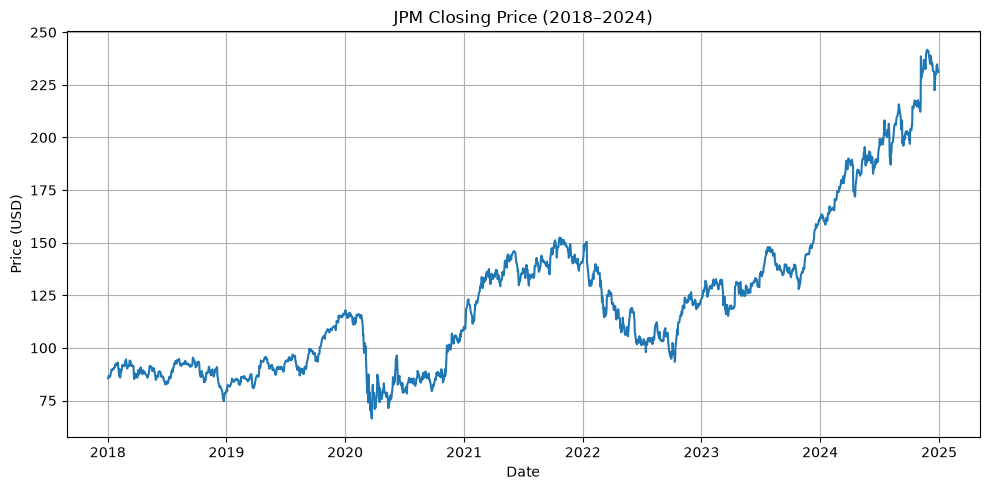

In [222]:
plt.figure(figsize=(10, 5))

plt.plot(
    market_data["Date"],
    market_data["Close"],
    linewidth=1.5
)

plt.title("JPM Closing Price (2018–2024)")
plt.xlabel("Date")
plt.ylabel("Price (USD)")

plt.grid(True)
plt.tight_layout()
plt.show()

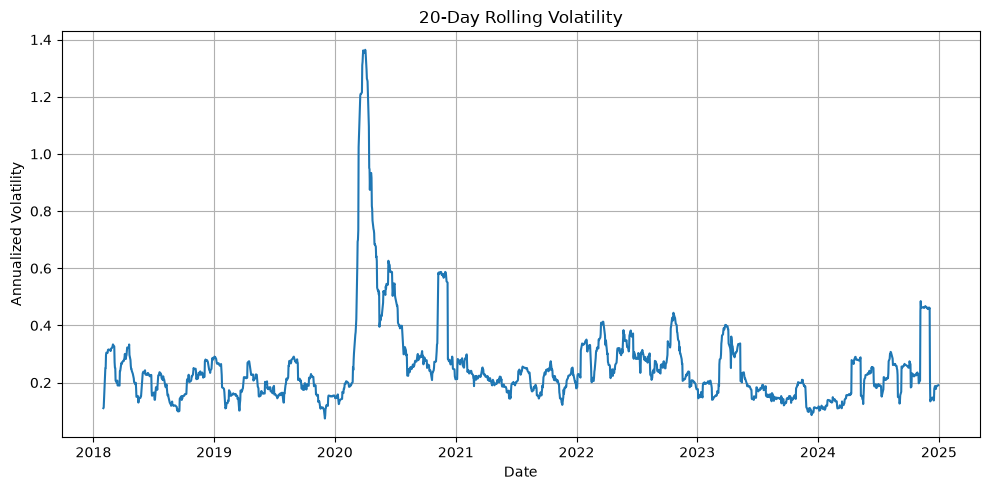

In [223]:
plt.figure(figsize=(10, 5))

plt.plot(
    market_data["Date"],
    market_data["Rolling_Volatility_20D"],
    linewidth=1.5
)

plt.title("20-Day Rolling Volatility")
plt.xlabel("Date")
plt.ylabel("Annualized Volatility")

plt.grid(True)
plt.tight_layout()
plt.show()

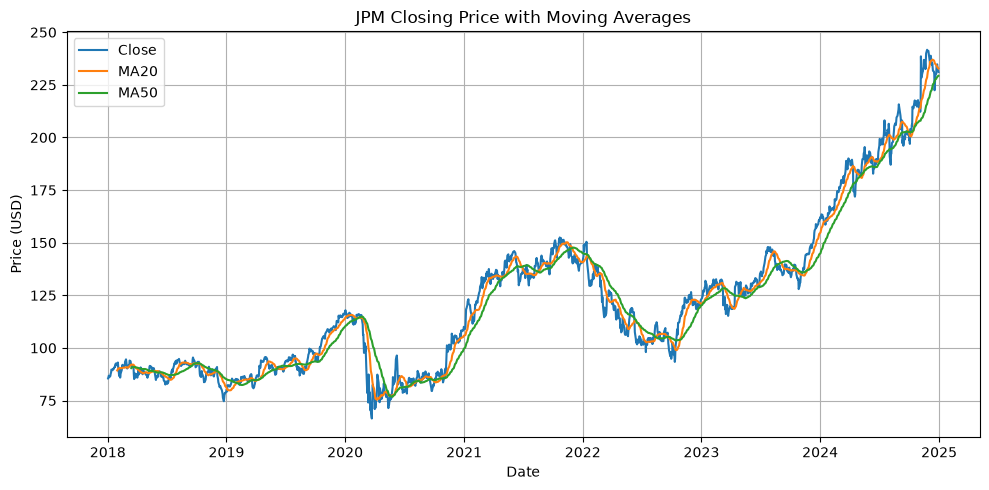

In [224]:
plt.figure(figsize=(10, 5))

plt.plot(
    market_data["Date"],
    market_data["Close"],
    label="Close",
    linewidth=1.5
)

plt.plot(
    market_data["Date"],
    market_data["Moving_Average_20D"],
    label="MA20",
    linewidth=1.5
)

plt.plot(
    market_data["Date"],
    market_data["Moving_Average_50D"],
    label="MA50",
    linewidth=1.5
)

plt.title("JPM Closing Price with Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price (USD)")

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

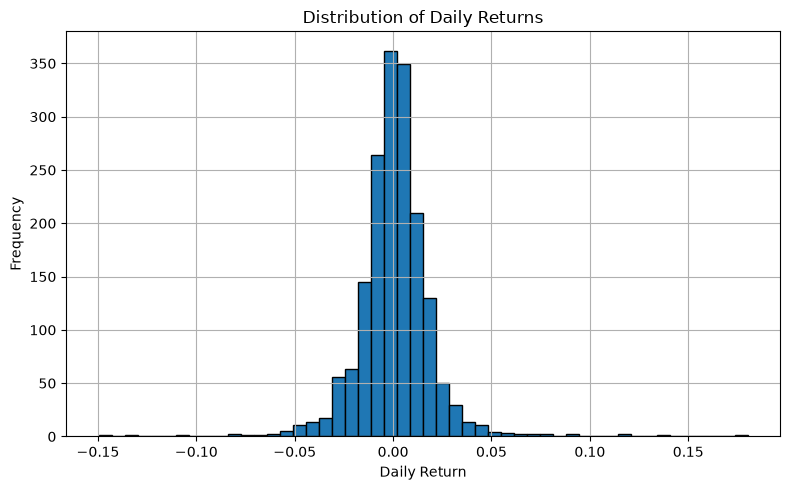

In [225]:
plt.figure(figsize=(8, 5))

plt.hist(
    market_data["Daily_Return"].dropna(),
    bins=50,
    edgecolor="black"
)

plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.grid(True)

plt.tight_layout()
plt.show()

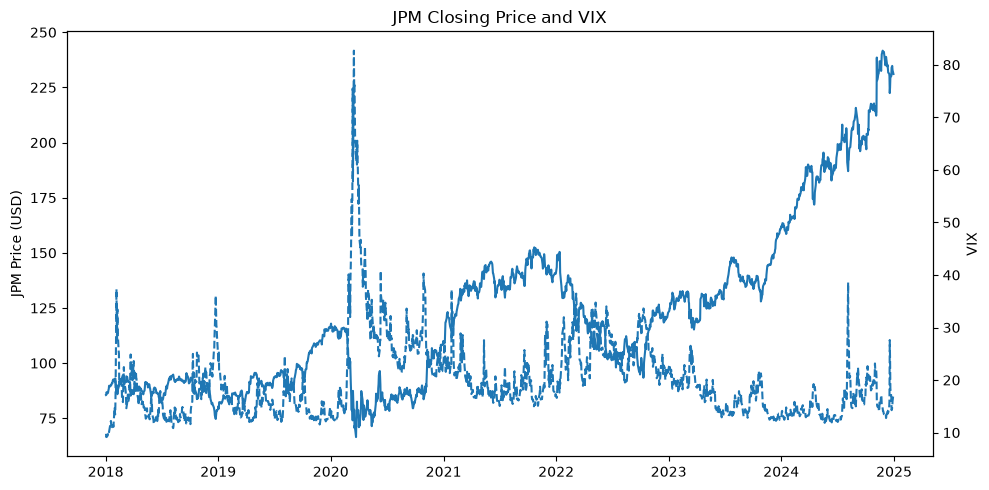

In [226]:
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(
    market_data["Date"],
    market_data["Close"],
    label="JPM Close"
)
ax1.set_ylabel("JPM Price (USD)")

ax2 = ax1.twinx()

ax2.plot(
    market_data["Date"],
    market_data["VIX_Close"],
    label="VIX",
    linestyle="--"
)
ax2.set_ylabel("VIX")

plt.title("JPM Closing Price and VIX")
plt.tight_layout()
plt.show()

In [232]:
market_data.describe()

,Date,Close,High,Low,Open,Volume,VIX_Close,Treasury_Rate,Daily_Return,Log_Return,Rolling_Volatility_20D,Moving_Average_20D,Moving_Average_50D,Price_Momentum_20D,Interest_Rate_Momentum,VIX_Return,VIX_JPM_Correlation_20D
count,1760,1760.000000,1760.000000,1760.000000,1760.000000,1.760000e+03,1760.000000,1760.000000,1759.000000,1759.000000,1740.000000,1741.000000,1711.000000,1740.000000,1759.000000,1759.000000,1740.000000
mean,2021-06-30 22:10:21.818181,122.424267,123.581355,121.236115,122.399530,1.322733e+07,19.871136,2.641553,0.000738,0.000565,0.253993,122.017837,121.318575,0.013914,0.001188,0.003797,-0.495317
min,2018-01-02 00:00:00,66.463898,70.433399,64.680999,68.591624,3.220500e+06,9.150000,0.520000,-0.149649,-0.162106,0.074440,75.386226,76.812147,-0.402013,-0.300000,-0.281566,-0.908261
25%,2019-10-01 18:00:00,90.884237,91.640737,89.880633,90.844907,8.989225e+06,14.477500,1.590000,-0.007775,-0.007805,0.170531,90.624695,90.781360,-0.026290,-0.030000,-0.043932,-0.687077
50%,2021-06-30 12:00:00,115.615894,116.351756,114.980956,115.635781,1.158615e+07,18.040001,2.790000,0.000668,0.000668,0.221800,115.034989,114.234375,0.013977,0.000000,-0.008021,-0.528311
75%,2023-03-30 06:00:00,139.184422,140.461207,138.035050,139.111591,1.516445e+07,22.892499,3.740000,0.009122,0.009080,0.278790,139.071912,138.660846,0.057130,0.030000,0.035117,-0.350422
max,2024-12-30 00:00:00,241.669739,245.551290,240.858680,241.862858,5.441880e+07,82.690002,4.980000,0.180125,0.165620,1.364336,236.957827,229.299013,0.289231,0.290000,1.155979,0.349257
std,NaN,37.523742,37.721172,37.280551,37.485610,6.575726e+06,7.713274,1.209314,0.018646,0.018608,0.157311,36.578578,34.996928,0.073921,0.057008,0.088510,0.241395


In [229]:
market_data.head()

,Date,Close,High,Low,Open,Volume,Volume_Outlier,VIX_Close,VIX_Close_Outlier,Treasury_Rate,...,Rolling_Volatility_20D,Moving_Average_20D,Moving_Average_50D,Price_Momentum_20D,Interest_Rate_Momentum,VIX_Return,VIX_JPM_Correlation_20D,Daily_Return_Outlier,Rolling_Volatility_20D_Outlier,Price_Momentum_20D_Outlier
0,2018-01-02,85.516029,85.571482,84.612943,85.262531,13578800,False,9.77,False,2.46,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False
1,2018-01-03,85.603180,85.943818,85.143719,85.444746,11901000,False,9.15,False,2.44,...,NaN,NaN,NaN,NaN,-0.02,-0.063460,NaN,False,False,False
2,2018-01-04,86.829483,87.617827,86.160581,86.287993,12953700,False,9.22,False,2.46,...,NaN,NaN,NaN,NaN,0.02,0.007650,NaN,False,False,False
3,2018-01-05,86.272064,87.235603,85.826133,87.004673,14155000,False,9.22,False,2.47,...,NaN,NaN,NaN,NaN,0.01,0.000000,NaN,False,False,False
4,2018-01-08,86.399475,86.542811,85.762426,86.120768,12466500,False,9.52,False,2.49,...,NaN,NaN,NaN,NaN,0.02,0.032538,NaN,False,False,False
